# 실습 6: 쓸 수 있는 표 한 벌로 만들기
- 상황: 쓸 수 없는 열은 걸러냈는데 아직도 수백 개가 남았다
- 목표: 겹치는 센서를 묶고 관련 있는 것부터 남겨 정제본 한 벌을 만든다

## Step 0. 폴더와 노트북 만들고, 앞 실습 선별까지 다시 만들기

In [1]:
import pandas as pd

# 맨 위 data 폴더 — 이 노트북 폴더에서 두 단계 위
df = pd.read_csv("../../data/04_secom.csv")   # 원본은 이대로 둔다

sensors = df.filter(like="sensor_")

# 버릴 센서 열 — 셋 중 하나라도 걸리면 제외한다
# | 는 '또는'. 겹치는 열이 있어도 한 번만 세어진다
버릴열 = (
    (sensors.isna().mean() * 100 >= 50)      # 빈칸 비율 50% 이상
    | (sensors.nunique() == 1)               # 값 종류가 1개 (상수열)
    | (sensors.std() <= 0.001)               # 표준편차 0.001 이하
)
남길센서 = sensors.columns[~버릴열]           # ~ 는 참/거짓 뒤집기

# 센서가 아닌 열(측정 시각, 판정)은 뒤에서 계속 쓰니 같이 남긴다
df1 = df[["measured_at", *남길센서, "result"]]

print("버린 센서 열:", int(버릴열.sum()), "개 / 남긴 센서 열:", len(남길센서), "개")
print()
print("원본 df 행/열:", df.shape)
print("df1    행/열:", df1.shape)

버린 센서 열: 154 개 / 남긴 센서 열: 436 개

원본 df 행/열: (1567, 592)
df1    행/열: (1567, 438)


## Step 1. 겹친다는 게 무슨 뜻인지 눈으로 보기

### 두 센서를 나란히 그려본다
같은 것을 재고 있는 것처럼 보이는 짝이 있는지 확인한다.

고른 센서: sensor_177 / sensor_448


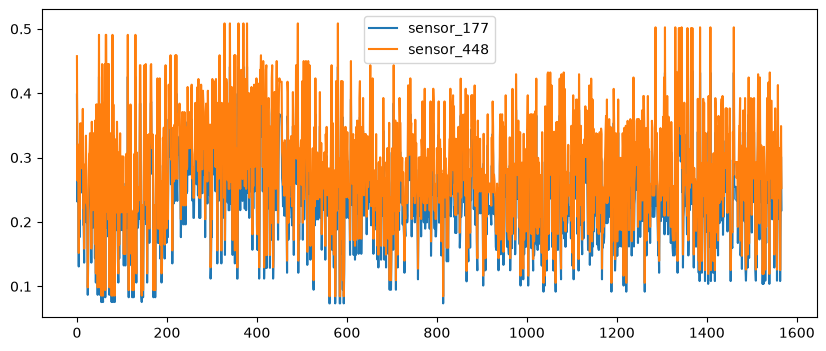

In [2]:
import matplotlib.pyplot as plt

# 실제로 겹치는 것으로 확인된 짝 (겹친다는 게 어떤 모양인지 보려고 미리 골라둔 두 개)
센서A = "sensor_177"
센서B = "sensor_448"

print("고른 센서:", 센서A, "/", 센서B)

# figure() - 그림판 하나를 편다. figsize 는 가로세로 크기(인치)
plt.figure(figsize=(10, 4))

# plot() - 값을 순서대로 선으로 잇는다. label 은 범례에 표시될 이름
plt.plot(df1[센서A].values, label=센서A)
plt.plot(df1[센서B].values, label=센서B)

# legend() - 어느 선이 무엇인지 알려주는 상자를 띄운다
plt.legend()
plt.show()

## Step 2. 겹치는 정도를 숫자로 재보기

### 용어 풀이 - 열끼리의 관계를 말할 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 상관관계 (correlation) | 두 열이 얼마나 같이 움직이는지. -1에서 1 사이의 숫자로 잰다 |
| 상관계수 1에 가깝다 | 하나가 오르면 다른 하나도 같이 오른다 |
| 상관계수 -1에 가깝다 | 하나가 오르면 다른 하나는 내려간다. 이것도 "관계가 강한" 것이다 |
| 상관계수 0에 가깝다 | 서로 상관없이 따로 논다 |
| 다중공선성 | 같은 말을 하는 열이 여러 개 섞여 있는 상태. 같은 정보를 여러 번 세는 셈이 된다 |
| 표준화 (standardization) | 단위가 다른 열들을 같은 자로 재도록 바꾸는 것 |
| 변수 선택 (feature selection) | 쓸 열을 골라내는 일 전체. 오늘 하는 일에 붙은 이름 |
| 관련도 | 이 실습에서 쓰는 말. 그 센서와 불량 여부(1/0)의 상관계수 절댓값을 가리킨다 |

**상관관계가 높다고 원인은 아니다.**<br>
아이스크림 판매량과 익사 사고는 같이 오르내리지만, 아이스크림이 원인은 아니다.<br>
둘 다 여름이라 그렇다. 숫자가 높게 나와도 "관계가 있어 보인다"까지만 말한다.

In [3]:
# corr() - 두 열이 얼마나 같이 움직이는지 -1 ~ 1 사이 숫자로 계산한다
겹침정도 = df1[센서A].corr(df1[센서B])

print(센서A, "와", 센서B, "의 상관계수:", round(겹침정도, 4))

sensor_177 와 sensor_448 의 상관계수: 0.9999


### 문법 노트 - 열끼리 비교하기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| .corr(다른열) | 두 열의 상관계수를 계산 | 그림 없이 숫자 하나로 겹침 정도를 잰다 |
| .values | 표의 값만 꺼낸다 | 그래프를 그릴 때 줄 번호가 아니라 값만 필요해서 |
| plt.plot() | 값을 순서대로 선으로 잇는다 | 두 센서 모양을 겹쳐 보기 위해 |
| plt.legend() | 어느 선이 무엇인지 표시 | 선이 둘 이상이면 없으면 구분이 안 된다 |

**부호는 무시하고 크기만 본다.**<br>
-0.9 와 0.9 는 방향만 반대일 뿐 "강하게 붙어 다닌다"는 점에서 같다.<br>
그래서 겹치는 짝을 찾을 때는 절댓값을 쓴다.

## Step 3. 겹치는 짝 전부 찾아 대표만 남기기

In [4]:
# df1의 센서 열들끼리 상관계수를 전부 계산하고, 겹치는 짝에서 하나씩만 남긴다

센서목록 = [c for c in df1.columns if c.startswith("sensor_")]

# corr() - 열끼리 모두 짝지어 상관계수를 계산한다 (436 x 436 표가 나온다)
상관표 = df1[센서목록].corr()

# stack() - 표를 (열A, 열B) -> 값 형태로 길게 편다
# 같은 짝이 두 번 나오지 않게, 이름 순서로 앞선 쪽만 남긴다 (자기 자신끼리도 빠진다)
모든짝 = 상관표.stack()
모든짝 = 모든짝[[a < b for a, b in 모든짝.index]]

# 부호는 무시하고 크기만 본다
높은짝 = 모든짝[모든짝.abs() >= 0.9].sort_values(key=abs, ascending=False)

print("센서 열:", len(센서목록), "개 →  짝의 수:", len(모든짝), "쌍")
print("절댓값 0.9 이상인 짝:", len(높은짝), "쌍")

# 상위 10쌍을 표로 (빈칸 개수도 같이 보여 어느 쪽을 남길지 알 수 있게)
빈칸수 = df1[센서목록].isna().sum()
상위10 = pd.DataFrame({
    "센서 A": [a for a, b in 높은짝.index[:10]],
    "센서 B": [b for a, b in 높은짝.index[:10]],
    "상관계수": 높은짝.values[:10].round(4),
    "A 빈칸": [빈칸수[a] for a, b in 높은짝.index[:10]],
    "B 빈칸": [빈칸수[b] for a, b in 높은짝.index[:10]],
})
print("\n[상위 10쌍]")
print(상위10.to_string(index=False))

# 겹치는 짝마다 하나만 남긴다 — 빈칸이 더 적은 쪽을 남기고 많은 쪽을 버린다
# 상관계수가 큰 짝부터 순서대로 훑는다
버릴센서 = set()
for (a, b), r in 높은짝.items():
    if a in 버릴센서 or b in 버릴센서:
        continue                      # 둘 중 하나가 이미 빠졌으면 넘어간다
    # 빈칸이 같으면 뒤쪽 이름(b)을 버린다
    버릴센서.add(b if 빈칸수[a] <= 빈칸수[b] else a)

# df와 df1은 건드리지 않고 새 이름으로 만든다
df2 = df1.drop(columns=list(버릴센서))

print("\n겹쳐서 버린 센서 열:", len(버릴센서), "개")
print("df1 열 수:", df1.shape[1])
print("df2 열 수:", df2.shape[1])
print("df2 행/열:", df2.shape)

센서 열: 436 개 →  짝의 수: 94830 쌍
절댓값 0.9 이상인 짝: 342 쌍

[상위 10쌍]
      센서 A       센서 B  상관계수  A 빈칸  B 빈칸
sensor_075 sensor_210   1.0     6     6
sensor_075 sensor_479   1.0     6     6
sensor_075 sensor_348   1.0     6     6
sensor_075 sensor_343   1.0     6     6
sensor_343 sensor_348   1.0     6     6
sensor_210 sensor_348   1.0     6     6
sensor_210 sensor_479   1.0     6     6
sensor_207 sensor_210   1.0     6     6
sensor_210 sensor_343   1.0     6     6
sensor_207 sensor_348   1.0     6     6

겹쳐서 버린 센서 열: 190 개
df1 열 수: 438
df2 열 수: 248
df2 행/열: (1567, 248)


## Step 4. 단위가 제각각이라는 것 확인하기

### 값의 크기가 열마다 얼마나 다른지 본다
같은 표에 들어 있어도 어떤 열은 0~1, 어떤 열은 수천일 수 있다.

In [5]:
# describe() - 열마다 개수, 평균, 표준편차, 최소, 최대 등을 한 번에 보여준다
# .T - 표를 가로세로 뒤집는다. 열이 많을 때는 세로로 봐야 읽힌다
# head() - 위에서 몇 줄만
df2.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
sensor_001,3014.452896,73.621787,2743.2400,3356.3500
sensor_002,2495.850231,80.407705,2158.7500,2846.4400
sensor_003,2200.547318,29.513152,2060.6600,2315.2667
sensor_004,1396.376627,441.691640,0.0000,3715.0417
sensor_007,101.112908,6.237214,82.1311,129.2522
sensor_008,0.121822,0.008961,0.0000,0.1286
sensor_009,1.462862,0.073897,1.1910,1.6564
sensor_010,-0.000841,0.015116,-0.0534,0.0749
sensor_011,0.000146,0.009302,-0.0349,0.0530
sensor_012,0.964353,0.012452,0.6554,0.9848


In [6]:
# 센서 열들의 평균만 모아서 가장 작은 값과 가장 큰 값을 본다
평균들 = df2.describe().T["mean"]

# idxmin() / idxmax() - 가장 작은(큰) 값이 어느 줄인지 그 이름을 돌려준다
print("평균이 가장 작은 열:", 평균들.idxmin(), "→", 평균들.min())
print("평균이 가장 큰 열:", 평균들.idxmax(), "→", 평균들.max())

평균이 가장 작은 열: sensor_022 → -5618.393610223642
평균이 가장 큰 열: sensor_091 → 8827.536865303431


표준편차가 가장 큰 열 : sensor_163 → 6553.5693
표준편차가 가장 작은 열: sensor_144 → 0.001282
두 열의 크기 차이     : 5112749 배

                   mean          std  min         max
sensor_163  4797.154633  6553.569317  0.0  36871.0000
sensor_144     0.004169     0.001282  0.0      0.0121

[표준화 후] 평균과 표준편차
      sensor_163  sensor_144
mean        -0.0        -0.0
std          1.0         1.0


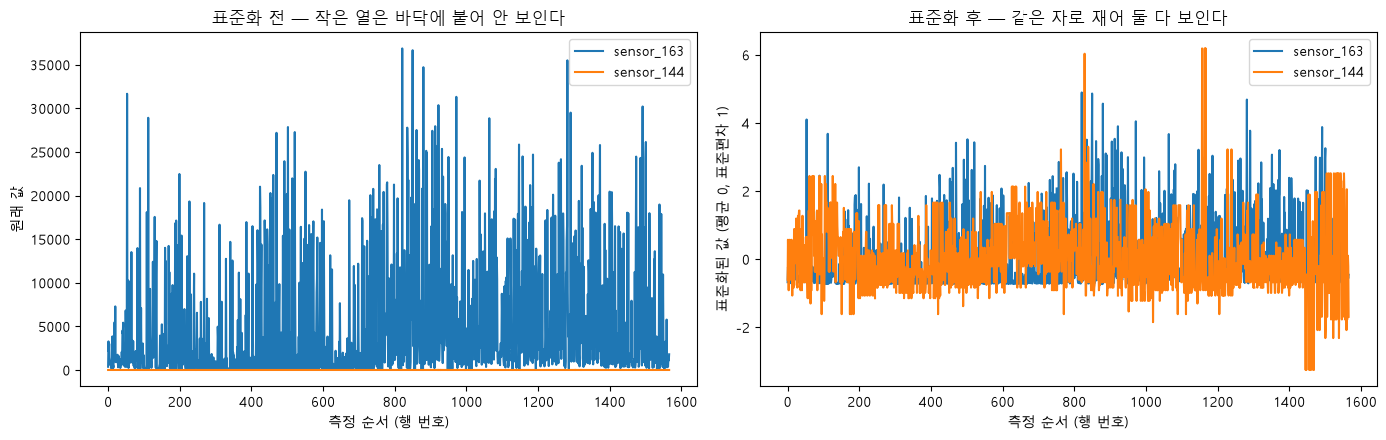


df2는 그대로: (1567, 248)


In [7]:
# 값의 크기가 가장 다른 두 열을 골라, 표준화 전/후를 나란히 그린다
# df2는 건드리지 않는다. 그림용으로만 계산한다

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글이 네모로 깨지지 않게
plt.rcParams["axes.unicode_minus"] = False

센서열 = [c for c in df2.columns if c.startswith("sensor_")]

# '값의 크기'는 흩어진 폭(표준편차)으로 본다. 가장 큰 열과 가장 작은 열을 고른다
표준편차들 = df2[센서열].std()
큰열 = 표준편차들.idxmax()
작은열 = 표준편차들.idxmin()

print("표준편차가 가장 큰 열 :", 큰열, "→", round(표준편차들[큰열], 4))
print("표준편차가 가장 작은 열:", 작은열, "→", round(표준편차들[작은열], 6))
print("두 열의 크기 차이     :", round(표준편차들[큰열] / 표준편차들[작은열]), "배")
print()
print(df2[[큰열, 작은열]].describe().T[["mean", "std", "min", "max"]])

# 표준화 — (값 - 평균) / 표준편차. 이렇게 하면 평균 0, 표준편차 1이 된다
표준화 = (df2[[큰열, 작은열]] - df2[[큰열, 작은열]].mean()) / df2[[큰열, 작은열]].std()

print("\n[표준화 후] 평균과 표준편차")
print(표준화.agg(["mean", "std"]).round(6))

# subplots(1, 2) - 그림판을 좌우 두 칸으로 나눈다
fig, (왼쪽, 오른쪽) = plt.subplots(1, 2, figsize=(14, 4.5))

왼쪽.plot(df2[큰열].values, label=큰열)
왼쪽.plot(df2[작은열].values, label=작은열)
왼쪽.set_title("표준화 전 — 작은 열은 바닥에 붙어 안 보인다")
왼쪽.set_xlabel("측정 순서 (행 번호)")
왼쪽.set_ylabel("원래 값")
왼쪽.legend()

오른쪽.plot(표준화[큰열].values, label=큰열)
오른쪽.plot(표준화[작은열].values, label=작은열)
오른쪽.set_title("표준화 후 — 같은 자로 재어 둘 다 보인다")
오른쪽.set_xlabel("측정 순서 (행 번호)")
오른쪽.set_ylabel("표준화된 값 (평균 0, 표준편차 1)")
오른쪽.legend()

plt.tight_layout()      # 두 그림이 겹치지 않게 간격을 잡아준다
plt.show()

print("\ndf2는 그대로:", df2.shape)

## Step 5. 결과와 관련 있는 열부터 순서대로 보기

In [8]:
# 판정을 숫자로 바꾸고, 센서마다 불량여부와의 관련도를 잰다

# 불량이면 1, 양품이면 0. 원래 result 열은 그대로 두고 새 열로 붙인다
df2["불량여부"] = (df2["result"] == "불량").astype(int)

print("불량여부 열 확인:")
print(df2["불량여부"].value_counts())
print("(원래 result 열도 그대로 있다:", "result" in df2.columns, ")")

센서열 = [c for c in df2.columns if c.startswith("sensor_")]

# corrwith() - 표의 각 열과 지정한 열의 상관계수를 한 번에 계산한다
관련도 = df2[센서열].corrwith(df2["불량여부"])

# 부호는 무시하고 크기만 본다. 큰 순으로 세운다
rank_table = (
    관련도.abs()
    .sort_values(ascending=False)
    .head(20)
    .rename("상관계수 절댓값")
    .rename_axis("센서")
    .reset_index()
)

print("\n[불량여부와 관련도 높은 상위 20개]")
rank_table

불량여부 열 확인:
불량여부
0    1463
1     104
Name: count, dtype: int64
(원래 result 열도 그대로 있다: True )

[불량여부와 관련도 높은 상위 20개]


C:\Users\rkdld\AppData\Local\Temp\ipykernel_63404\2491011879.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df2["불량여부"] = (df2["result"] == "불량").astype(int)


,센서,상관계수 절댓값
0,sensor_060,0.155796
1,sensor_104,0.151203
2,sensor_511,0.131593
3,sensor_432,0.120851
4,sensor_431,0.110067
5,sensor_022,0.108488
6,sensor_029,0.107252
7,sensor_130,0.103373
8,sensor_211,0.102545
9,sensor_164,0.100330


In [9]:
# 1등 센서가 양품일 때와 불량일 때 실제로 다른 값을 보이는지 확인한다

일등 = rank_table.loc[0, "센서"]        # rank_table 맨 윗줄의 센서 이름
print("1등 센서:", 일등, " (관련도", round(rank_table.loc[0, "상관계수 절댓값"], 4), ")")

# groupby("result") - 판정이 같은 행끼리 묶는다. 그 묶음마다 평균을 낸다
판정별 = df2.groupby("result")[일등].agg(["count", "mean", "std"]).round(4)
판정별.columns = ["건수", "평균", "표준편차"]

print("\n[판정별 " + 일등 + " 값]")
print(판정별)

양품평균 = 판정별.loc["양품", "평균"]
불량평균 = 판정별.loc["불량", "평균"]
전체표준편차 = df2[일등].std()

print("\n두 평균의 차이:", round(불량평균 - 양품평균, 4))
print("이 열 전체의 표준편차:", round(전체표준편차, 4))
print("차이를 표준편차로 나누면:", round(abs(불량평균 - 양품평균) / 전체표준편차, 3), "배")
print("→ 평소 흩어진 폭에 비해 두 무리의 평균 차이가 얼마나 되는지를 보는 값이다")

1등 센서: sensor_060  (관련도 0.1558 )

[판정별 sensor_060 값]
          건수      평균     표준편차
result                       
불량       104  8.5151  10.8023
양품      1456  2.5635   9.3131

두 평균의 차이: 5.9516
이 열 전체의 표준편차: 9.5322
차이를 표준편차로 나누면: 0.624 배
→ 평소 흩어진 폭에 비해 두 무리의 평균 차이가 얼마나 되는지를 보는 값이다


## Step 6. 정제본 저장하고 숫자 검산하기

In [10]:
# 관련도 상위 50개 센서와 판정만 남겨 정제본을 만들고 파일로 저장한다
from pathlib import Path

# rank_table에는 상위 20개만 담아뒀으므로, 50개는 관련도에서 다시 뽑는다
상위50 = 관련도.abs().sort_values(ascending=False).head(50).index.tolist()

df3 = df2[[*상위50, "result"]]

# 이 실습 폴더 안의 results 폴더에 저장한다
저장폴더 = Path("results")
저장폴더.mkdir(exist_ok=True)
저장경로 = 저장폴더 / "secom_clean.csv"

# index=False - 왼쪽 줄번호는 저장하지 않는다
# encoding="utf-8-sig" - 엑셀에서 열어도 한글이 안 깨지게
df3.to_csv(저장경로, index=False, encoding="utf-8-sig")

print("저장함:", 저장경로, "(", 저장경로.stat().st_size, "바이트 )")

# 1. df3 크기
print("\n1) df3 행/열:", df3.shape)

# 2, 3. 불량 비율 — (조건이 참인 비율) x 100
df3불량 = (df3["result"] == "불량").mean() * 100
df불량 = (df["result"] == "불량").mean() * 100

print("2) df3 불량 비율:", round(df3불량, 2), "%")
print("3) 원본 df 불량 비율:", round(df불량, 2), "%")
print("   두 값이 같은가:", round(df3불량, 10) == round(df불량, 10))

저장함: results\secom_clean.csv ( 542557 바이트 )

1) df3 행/열: (1567, 51)
2) df3 불량 비율: 6.64 %
3) 원본 df 불량 비율: 6.64 %
   두 값이 같은가: True


## Step 7. 단계별로 몇 개가 되었는지 채워 넣기

### 단계별 열 수

| 단계 | 적용한 기준 | 남은 센서 열 수 |
|---|---|---|
| 시작 | - | 590 |
| 1차 선별 | 빈칸 [50]% 이상 · 상수열 · 표준편차 [0.001] 이하 제외 | [436] |
| 겹침 정리 | 상관계수 절댓값 [0.9] 이상이면 하나만 남김 | [312] |
| 관련도 선별 | 순위 상위 [50]개 | [50] |

### 저장 결과

| 항목 | 값 |
|---|---|
| 정제본 행 수 | [1567] |
| 정제본 열 수 (검사 결과 포함) | [51] |
| 정제본 불합격 비율 | [6.6]% |
| 원본 불합격 비율 | [6.6]% |

---
## 직접 해보기 (도전) - 기준을 바꿔 두 번째 정제본 만들기

- 상황: 상위 50개로 잘랐는데, 20개로 자르면 무엇이 달라지는지 아직 모른다
- 할 일: 개수 기준만 바꿔 두 번째 정제본을 만들고 숫자를 비교한다
- 결과물: 정제본 파일 1개 추가 + 세 줄짜리 비교표 1개

In [11]:
# 개수 기준만 바꾼 두 번째 정제본(B)을 만들고 A와 비교한다
# 앞에서 만든 df2, df3, rank_table은 건드리지 않는다

관련도절댓값 = 관련도.abs()

A센서 = 상위50                                  # 정제본 A - 상위 50개 (앞에서 만든 것)
B센서 = rank_table["센서"].tolist()             # 정제본 B - rank_table의 상위 20개

df3b = df2[[*B센서, "result"]]

저장경로B = Path("results") / "secom_clean_b.csv"
df3b.to_csv(저장경로B, index=False, encoding="utf-8-sig")
print("저장함:", 저장경로B, "(", 저장경로B.stat().st_size, "바이트 )")

# set() - 순서를 무시한 모음. & 는 양쪽에 다 들어 있는 것만 남긴다(교집합)
공통 = set(A센서) & set(B센서)

비교 = pd.DataFrame([
    {
        "정제본": "A (상위 50개)",
        "열 수": df3.shape[1],
        "공통 센서 열": len(공통),
        "관련도 최솟값": round(관련도절댓값[A센서].min(), 6),
    },
    {
        "정제본": "B (상위 20개)",
        "열 수": df3b.shape[1],
        "공통 센서 열": len(공통),
        "관련도 최솟값": round(관련도절댓값[B센서].min(), 6),
    },
]).set_index("정제본")

print("\ndf3b 행/열:", df3b.shape)
print("앞에서 만든 것 그대로 — df2:", df2.shape, "/ df3:", df3.shape, "/ rank_table:", rank_table.shape)
비교

저장함: results\secom_clean_b.csv ( 223327 바이트 )

df3b 행/열: (1567, 21)
앞에서 만든 것 그대로 — df2: (1567, 249) / df3: (1567, 51) / rank_table: (20, 2)


,열 수,공통 센서 열,관련도 최솟값
정제본,,,
A (상위 50개),51,20,0.051873
B (상위 20개),21,20,0.078378


### 정제본 A vs B

| 항목 | A (상위 50) | B (상위 20) |
|---|---|---|
| 열 수 | [50] | [20] |
| 공통으로 들어간 열 수 | [20] | [20] |
| 관련도 최솟값 | [0.041] | [0.078] |